# 04 — Optimisation and Evaluation

This notebook completes the model development pipeline:

1. **Hyperparameter tuning** via `RandomizedSearchCV` with `GroupKFold`
2. **Threshold optimization** to maximize F1 for clinical deployment
3. **Final evaluation** with PR/ROC curves, lead-time analysis, and feature importance

> **Modules Used**: `src.data_loader`, `src.features`, `src.evaluation`, `src.tuning`

In [1]:
import sys
sys.path.insert(0, '..')

from src.data_loader import load_gold_table, train_test_split_by_stay
from src.features import prepare_features, get_feature_columns, NUMERIC_FEATURES
from src.evaluation import (
    compute_metrics, compute_metrics_at_threshold, compute_curves,
    compute_lead_time, compare_models
)
from src.tuning import (
    tune_logistic_regression, tune_xgboost, find_optimal_threshold
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 4.1 Data Loading

In [2]:
df = load_gold_table()
train_df, test_df = train_test_split_by_stay(df)

# Prepare feature matrices
X_train_lr, y_train, scaler = prepare_features(train_df, scale=True)
X_test_lr, y_test, _ = prepare_features(test_df, scale=True, scaler=scaler)

X_train_xgb, _, _ = prepare_features(train_df, scale=False)
X_test_xgb, _, _ = prepare_features(test_df, scale=False)

Loaded 2,304,561 hourly samples across 72,082 stays.
Train: 1,842,484 samples (57,665 stays)
Test:  462,077 samples (14,417 stays)


## 4.2 Hyperparameter Tuning

We use `RandomizedSearchCV` with `GroupKFold` (5 folds, grouped by `stay_id`) and **AUPRC** as the scoring metric.


### 4.2.1 Tune Logistic Regression

In [3]:
lr_tuning = tune_logistic_regression(
    X_train_lr, y_train,
    groups=train_df['stay_id'],
    n_iter=20,
    n_folds=5
)

print(f"\nBest Logistic Regression parameters:")
for k, v in lr_tuning['best_params'].items():
    print(f"  {k}: {v}")

/Users/marcellpetras/Desktop/AKI-Medallion-Lakehouse/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/marcellpetras/Desktop/AKI-Medallion-Lakehouse/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/marcellpetras/Desktop/AKI-Medallion-Lakehouse/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logist

LR Tuning Complete — Best AUPRC: 0.2376
  Best params: {'C': np.float64(59.242456886204245), 'l1_ratio': np.float64(0.046450412719997725), 'solver': 'saga'}

Best Logistic Regression parameters:
  C: 59.242456886204245
  l1_ratio: 0.046450412719997725
  solver: saga


### 4.2.2 Tune XGBoost

In [4]:
xgb_tuning = tune_xgboost(
    X_train_xgb, y_train,
    groups=train_df['stay_id'],
    n_iter=30,
    n_folds=5
)

print(f"\nBest XGBoost parameters:")
for k, v in xgb_tuning['best_params'].items():
    print(f"  {k}: {v}")

XGB Tuning Complete — Best AUPRC: 0.3908
  Best params: {'colsample_bytree': np.float64(0.6197809453334862), 'learning_rate': np.float64(0.05201951290645469), 'max_depth': 6, 'min_child_weight': 6, 'n_estimators': 346, 'subsample': np.float64(0.8688542189623514)}

Best XGBoost parameters:
  colsample_bytree: 0.6197809453334862
  learning_rate: 0.05201951290645469
  max_depth: 6
  min_child_weight: 6
  n_estimators: 346
  subsample: 0.8688542189623514


## 4.3 Retrain with Best Parameters

The `RandomizedSearchCV` object automatically refits the best model on the full training set (`refit=True`). We extract the tuned models and generate predictions on the held-out test set.

In [5]:
# Extract the tuned models (already fitted on full training set)
lr_tuned = lr_tuning['best_estimator']
xgb_tuned = xgb_tuning['best_estimator']

# Generate test set probabilities
lr_probs_tuned = lr_tuned.predict_proba(X_test_lr)[:, 1]
xgb_probs_tuned = xgb_tuned.predict_proba(X_test_xgb)[:, 1]

# Quick comparison: default threshold (0.5)
lr_metrics_tuned = compute_metrics(y_test, lr_probs_tuned)
xgb_metrics_tuned = compute_metrics(y_test, xgb_probs_tuned)

print("Tuned models (threshold=0.5):")
print(f"  LR  — AUPRC: {lr_metrics_tuned['auprc']:.4f} | AUROC: {lr_metrics_tuned['auroc']:.4f}")
print(f"  XGB — AUPRC: {xgb_metrics_tuned['auprc']:.4f} | AUROC: {xgb_metrics_tuned['auroc']:.4f}")

Tuned models (threshold=0.5):
  LR  — AUPRC: 0.2351 | AUROC: 0.7546
  XGB — AUPRC: 0.3976 | AUROC: 0.8129


## 4.4 Threshold Optimisation

The default decision threshold of 0.5 is rarely optimal for imbalanced clinical data. So we sweep all thresholds on the Precision-Recall curve and select the one that maximizes the **F1 score**, which balances precision (avoiding false alarms) and recall (catching true AKI cases).

In [6]:
print("--- Logistic Regression ---")
lr_threshold = find_optimal_threshold(y_test, lr_probs_tuned, strategy='f1')

print("\n--- XGBoost ---")
xgb_threshold = find_optimal_threshold(y_test, xgb_probs_tuned, strategy='f1')

--- Logistic Regression ---
Optimal threshold (f1): 0.6059
  Precision: 0.2284  |  Recall: 0.5061  |  F1: 0.3147

--- XGBoost ---
Optimal threshold (f1): 0.6971
  Precision: 0.3706  |  Recall: 0.4674  |  F1: 0.4134


## 4.5 Final Evaluation (Tuned Parameters + Optimal Threshold)

In [7]:
# Evaluate at optimal thresholds
lr_final = compute_metrics_at_threshold(y_test, lr_probs_tuned, lr_threshold['threshold'])
xgb_final = compute_metrics_at_threshold(y_test, xgb_probs_tuned, xgb_threshold['threshold'])

final_comparison = compare_models({
    'Logistic Regression (tuned)': lr_final,
    'XGBoost (tuned)': xgb_final,
})
display(final_comparison)

,AUPRC,AUROC,Precision,Recall,F1
Model,,,,,
Logistic Regression (tuned),0.2351,0.7546,0.2284,0.5061,0.3147
XGBoost (tuned),0.3976,0.8129,0.3706,0.4674,0.4134


### Confusion Matrices

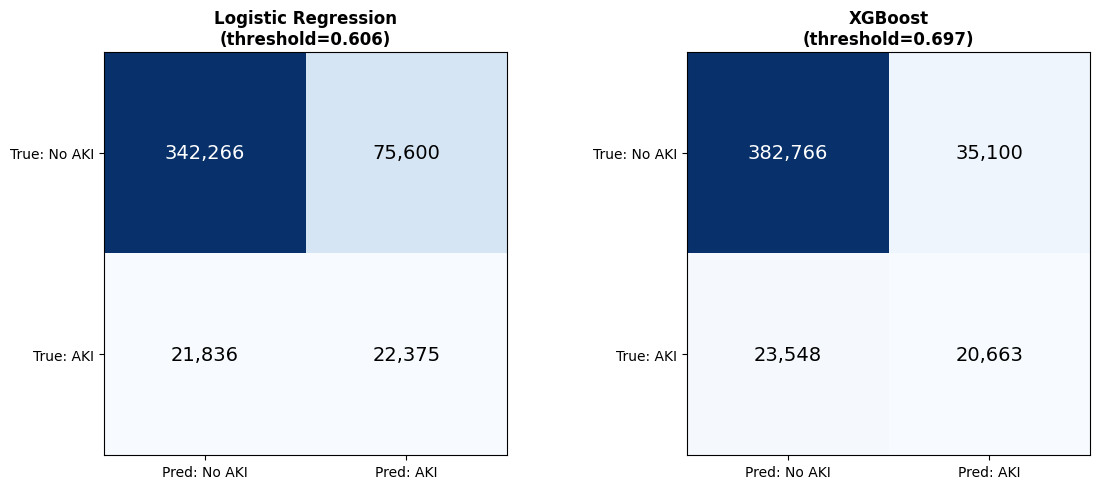

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, metrics) in zip(axes, [('Logistic Regression', lr_final), ('XGBoost', xgb_final)]):
    cm = metrics['confusion_matrix']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No AKI', 'Pred: AKI'])
    ax.set_yticklabels(['True: No AKI', 'True: AKI'])
    ax.set_title(f'{name}\n(threshold={metrics["threshold"]:.3f})', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

## 4.6 Precision-Recall & ROC Curves

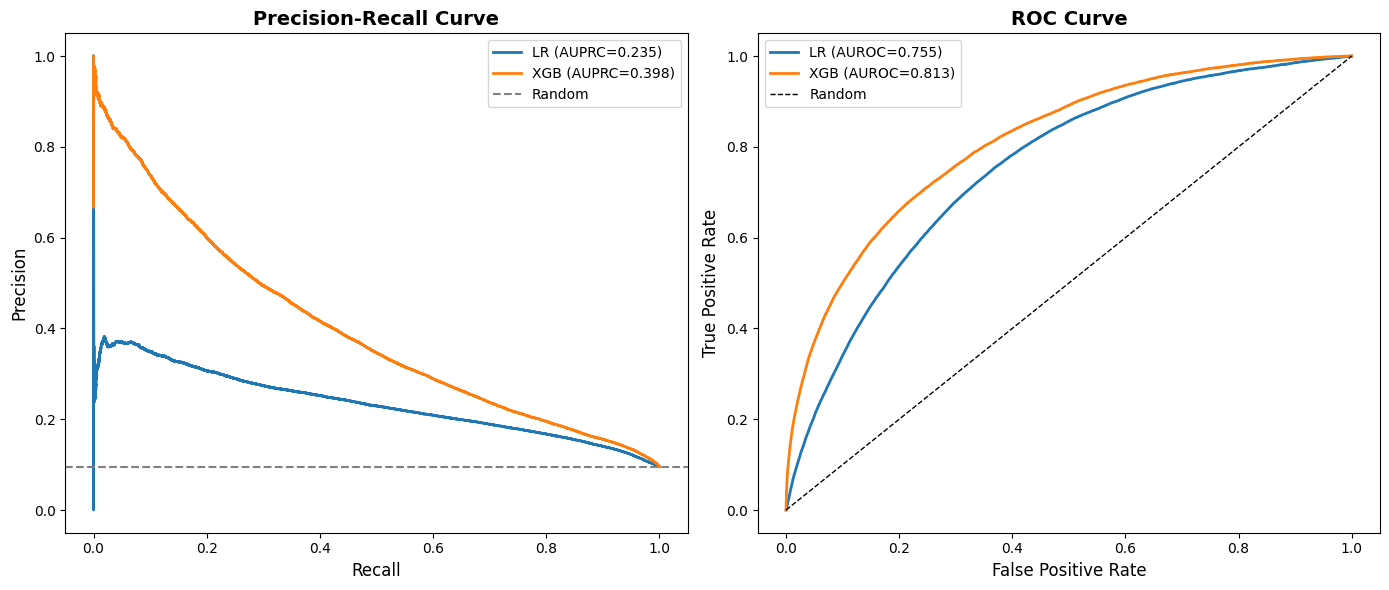

In [9]:
lr_curves = compute_curves(y_test, lr_probs_tuned)
xgb_curves = compute_curves(y_test, xgb_probs_tuned)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# PR Curve
ax1.plot(lr_curves['pr']['recall'], lr_curves['pr']['precision'],
         label=f"LR (AUPRC={lr_final['auprc']:.3f})", linewidth=2)
ax1.plot(xgb_curves['pr']['recall'], xgb_curves['pr']['precision'],
         label=f"XGB (AUPRC={xgb_final['auprc']:.3f})", linewidth=2)
ax1.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Random')
ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)

# ROC Curve
ax2.plot(lr_curves['roc']['fpr'], lr_curves['roc']['tpr'],
         label=f"LR (AUROC={lr_final['auroc']:.3f})", linewidth=2)
ax2.plot(xgb_curves['roc']['fpr'], xgb_curves['roc']['tpr'],
         label=f"XGB (AUROC={xgb_final['auroc']:.3f})", linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4.7 Lead-Time Analysis

For true positive predictions, we measure how many hours before the KDIGO criteria would have flagged the patient the ML model raised its alarm. Positive lead time means the model provides **earlier warning** than the rule-based standard of care.

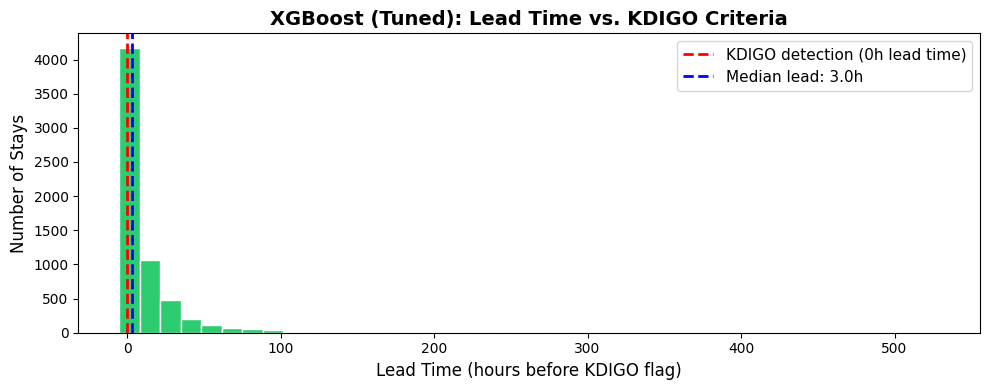


Lead-Time Statistics:
  Median: 3.0 hours
  Mean:   12.4 hours
  Stays with positive lead time: 3837 / 6301


In [10]:
xgb_lead = compute_lead_time(test_df, xgb_probs_tuned, threshold=xgb_threshold['threshold'])

if len(xgb_lead) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(xgb_lead['lead_time_hours'], bins=40, color='#2ECC71', edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='KDIGO detection (0h lead time)')
    median_lead = xgb_lead['lead_time_hours'].median()
    ax.axvline(x=median_lead, color='blue', linestyle='--', linewidth=2, label=f'Median lead: {median_lead:.1f}h')
    ax.set_xlabel('Lead Time (hours before KDIGO flag)', fontsize=12)
    ax.set_ylabel('Number of Stays', fontsize=12)
    ax.set_title('XGBoost (Tuned): Lead Time vs. KDIGO Criteria', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"\nLead-Time Statistics:")
    print(f"  Median: {xgb_lead['lead_time_hours'].median():.1f} hours")
    print(f"  Mean:   {xgb_lead['lead_time_hours'].mean():.1f} hours")
    print(f"  Stays with positive lead time: {(xgb_lead['lead_time_hours'] > 0).sum()} / {len(xgb_lead)}")
else:
    print('No true positive predictions to analyse.')

## 4.8 Feature Importance (XGBoost)

XGBoost provides gain-based feature importance, which measures the total reduction in the loss function contributed by each feature across all trees.

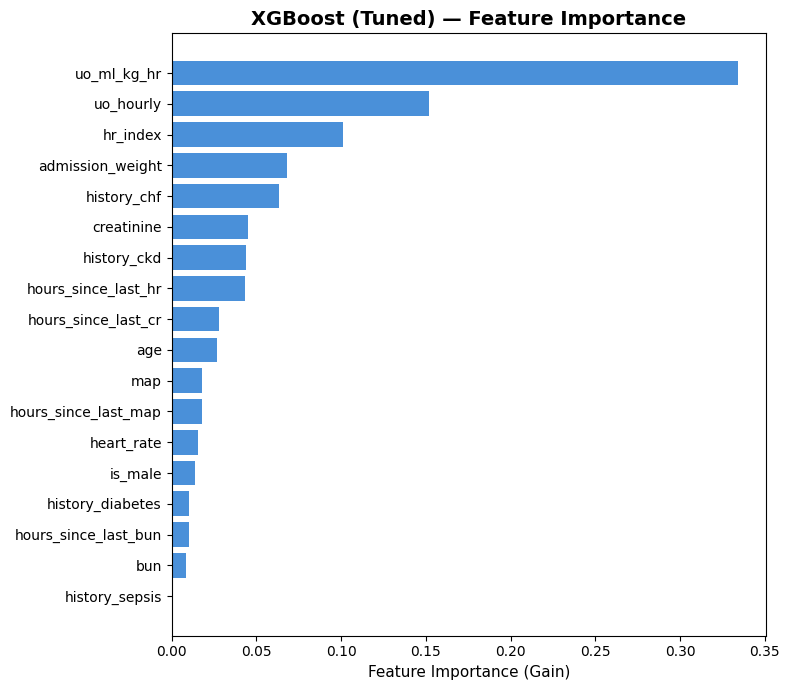

In [11]:
feature_names = get_feature_columns()
importances = xgb_tuned.feature_importances_

sorted_idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='#4A90D9')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('XGBoost (Tuned) — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()